### Read SNOWPACK Output Snow Depth and Compare 

Notebook contents 
* we have test simulations of from SNOWPACK at Powder Patch with HRRR forcing from WY2024. Let's read and compare with obs 

created by Cassie Lumbrazo\
last updated: Feb 2026\
run location: UAS linux\
python environment: **xarray**

In [22]:
# import packages 
%matplotlib inline

# plotting packages 
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns 

sns.set_theme()
# plt.rcParams['figure.figsize'] = [12,6] #overriding size

# data packages 
import pandas as pd
import numpy as np
import xarray as xr
from datetime import datetime

import scipy
import os

In [23]:
# set some seaborn plotting constants so that all plots look the same
sns.set_theme()
plt.rcParams['figure.figsize'] = [12,6] #overriding size

In [24]:
pwd

'/home/cassie/python/repos/snow_model_output'

# Function for Reading SMET Files 

In [25]:
def read_smet(filepath):
    header = {}
    fields = None
    data_start = None

    # Read file and parse header
    with open(filepath, "r") as f:
        lines = f.readlines()

    for i, line in enumerate(lines):
        line = line.strip()

        # Detect fields line
        if line.startswith("fields"):
            fields = line.split("=")[1].strip().split()

        # Detect start of data
        if line == "[DATA]":
            data_start = i + 1
            break

        # Parse header key-value pairs
        if "=" in line and not line.startswith("["):
            key, value = line.split("=", 1)
            header[key.strip()] = value.strip()

    if fields is None:
        raise ValueError("No 'fields' line found in SMET header.")
    if data_start is None:
        raise ValueError("No [DATA] section found.")

    # Read data into DataFrame
    df = pd.read_csv(
        filepath,
        skiprows=data_start,
        delim_whitespace=True,
        names=fields,
        parse_dates=["timestamp"]
    )

    # Set timestamp as index
    df = df.set_index("timestamp")

    # Convert to xarray
    ds = xr.Dataset.from_dataframe(df)

    return ds, header

In [26]:
ds_snowpack, header = read_smet("/home/cassie/python/models/run_snowpack/test1/output/HRRR_POINT_precip_accum_in_smet.smet")

print(ds_snowpack)
print(header)

<xarray.Dataset> Size: 2MB
Dimensions:               (timestamp: 2967)
Coordinates:
  * timestamp             (timestamp) datetime64[ns] 24kB 2023-10-01T05:00:00...
Data variables: (12/63)
    Qs                    (timestamp) float64 24kB 340.2 317.9 ... 10.84 3.142
    Ql                    (timestamp) float64 24kB 331.3 309.2 ... 5.348 0.417
    Qg                    (timestamp) float64 24kB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    TSG                   (timestamp) float64 24kB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    Qg0                   (timestamp) float64 24kB -999.0 -999.0 ... 0.0 0.0
    Qr                    (timestamp) float64 24kB 8.188 4.834 3.698 ... 0.0 0.0
    ...                    ...
    zSs                   (timestamp) float64 24kB 0.0 0.0 0.0 ... 119.8 119.8
    Ss                    (timestamp) float64 24kB 6.0 6.0 6.0 ... 0.05 0.05
    zS4                   (timestamp) float64 24kB 0.0 0.0 0.0 ... 119.8 119.8
    S4                    (timestamp) float64 24kB 6.0 6.0 6.0 ... 1.05

/tmp/ipykernel_1545854/1183788903.py:33: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(


In [27]:
ds_snowpack

<xarray.Dataset> Size: 2MB
Dimensions:               (timestamp: 2967)
Coordinates:
  * timestamp             (timestamp) datetime64[ns] 24kB 2023-10-01T05:00:00...
Data variables: (12/63)
    Qs                    (timestamp) float64 24kB 340.2 317.9 ... 10.84 3.142
    Ql                    (timestamp) float64 24kB 331.3 309.2 ... 5.348 0.417
    Qg                    (timestamp) float64 24kB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    TSG                   (timestamp) float64 24kB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    Qg0                   (timestamp) float64 24kB -999.0 -999.0 ... 0.0 0.0
    Qr                    (timestamp) float64 24kB 8.188 4.834 3.698 ... 0.0 0.0
    ...                    ...
    zSs                   (timestamp) float64 24kB 0.0 0.0 0.0 ... 119.8 119.8
    Ss                    (timestamp) float64 24kB 6.0 6.0 6.0 ... 0.05 0.05
    zS4                   (timestamp) float64 24kB 0.0 0.0 0.0 ... 119.8 119.8
    S4                    (timestamp) float64 24kB 6.0 6.0 6.0 ... 1.05 1.05
    zS5                   (timestamp) float64 24kB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    S5                    (timestamp) float64 24kB -999.0 -999.0 ... 0.987 0.98

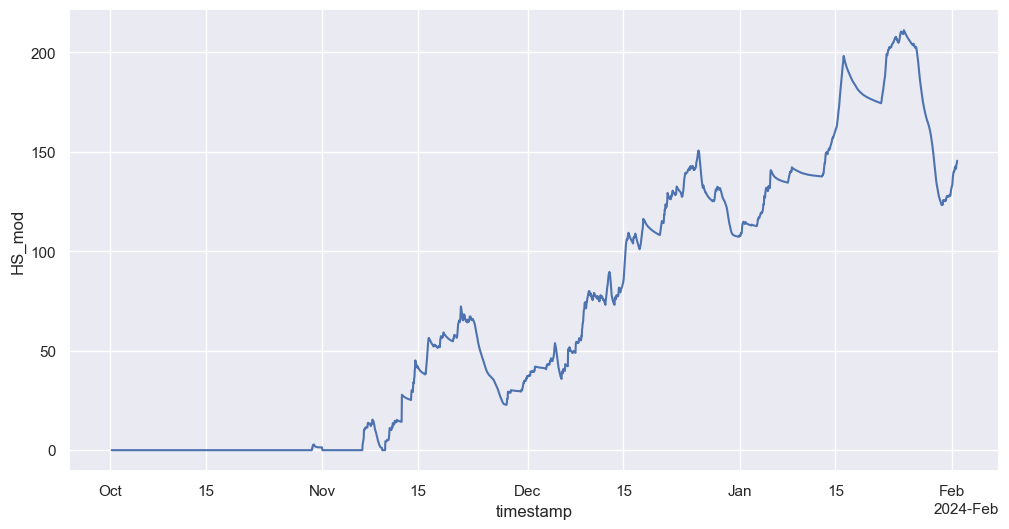

In [28]:
ds_snowpack.HS_mod.plot()

Open Obs Data at Powder Patch

In [29]:
# download mesonet data as well to plot this with the Mesowest data...
filename = '/home/cassie/data/fishcreek/mesonet/rawdata/PowderPatch_everything_until_1June2025.txt'
df_met = pd.read_csv(filename, sep = ",")

# make utc_valid a datetime and index the df_met by it 
df_met['datetime'] = pd.to_datetime(df_met['utc_valid'], utc=True)
df_met = df_met.set_index('datetime')
df_met.head()

df_met.head()

,station,utc_valid,PCIRZZ,PCIRZZZ,RNIRZZ,SDIRZZ,SDIRZZZ,TAIRZZ,TAIRZZZ,UDIRZZ,UHIRZZZ,UPIRZZ,UPIRZZZ,USIRZZ,USIRZZZ,VBIRZZ,VBIRZZZ,XRIRZZ,XRIRZZZ
datetime,,,,,,,,,,,,,,,,,,,
2010-12-15 22:00:00+00:00,PPSA2,2010-12-15 22:00:00,NaN,NaN,0.0,35.0,NaN,18.0,NaN,170.0,NaN,NaN,NaN,1.790,NaN,NaN,NaN,80.20,NaN
2011-01-09 04:15:00+00:00,PPSA2,2011-01-09 04:15:00,NaN,NaN,NaN,55.0,NaN,22.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,71.00,NaN
2011-05-21 03:45:00+00:00,PPSA2,2011-05-21 03:45:00,NaN,NaN,0.0,90.0,NaN,50.3,NaN,102.0,NaN,NaN,NaN,0.631,NaN,NaN,NaN,73.79,NaN
2011-05-21 04:15:00+00:00,PPSA2,2011-05-21 04:15:00,NaN,NaN,0.0,90.0,NaN,45.7,NaN,103.0,NaN,NaN,NaN,1.060,NaN,NaN,NaN,84.80,NaN
2011-05-21 04:45:00+00:00,PPSA2,2011-05-21 04:45:00,NaN,NaN,0.0,90.0,NaN,44.5,NaN,110.0,NaN,NaN,NaN,1.270,NaN,NaN,NaN,87.10,NaN


<Axes: xlabel='datetime'>

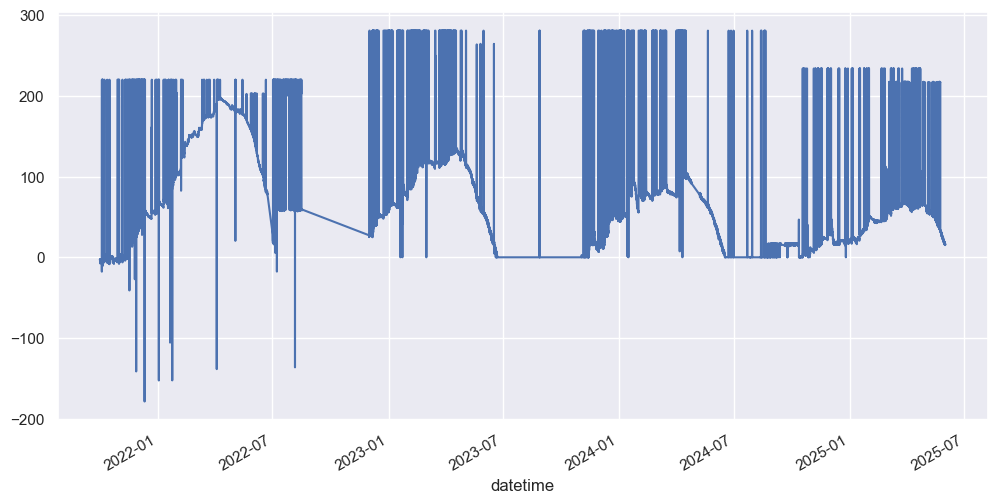

In [30]:
# save only snow depth SDIRZZ
df_met.SDIRZZZ.plot()

In [31]:
# quick clean 
df_met['hs'] = df_met['SDIRZZZ'].where(
    (df_met['SDIRZZZ'] >= 0) & (df_met['SDIRZZZ'] <= 200)
)

df_met = df_met.loc['2023-10-01':'2024-02-01', ['hs']]
df_met

,hs
datetime,
2023-10-16 18:00:00+00:00,0.0
2023-10-16 19:00:00+00:00,0.0
2023-10-16 20:00:00+00:00,0.0
2023-10-16 21:00:00+00:00,0.0
2023-10-16 22:00:00+00:00,0.0
...,...
2024-02-01 19:00:00+00:00,NaN
2024-02-01 20:00:00+00:00,NaN
2024-02-01 21:00:00+00:00,NaN


In [ ]:
# The raw data is in inches, convert to cm
df_met = df_met * 2.54

In [33]:
mask = (df_met.index.month == 11) & (df_met['hs'] > 100)

# set those values to NaN
df_met.loc[mask, 'hs'] = np.nan

Text(0, 0.5, 'snow depth (cm)')

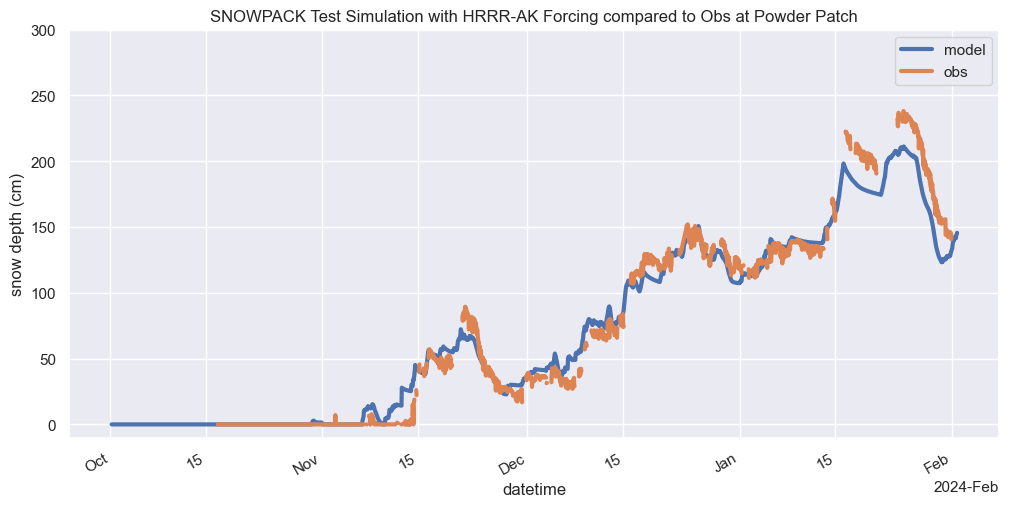

In [34]:
ds_snowpack.HS_mod.plot(label = 'model', linewidth = 3)
df_met.hs.plot(label = 'obs', linewidth = 3)

plt.title('SNOWPACK Test Simulation with HRRR-AK Forcing compared to Obs at Powder Patch')
plt.legend()

plt.ylim([-10, 300])

plt.ylabel('snow depth (cm)')

In [35]:
ds_snowpack

<xarray.Dataset> Size: 2MB
Dimensions:               (timestamp: 2967)
Coordinates:
  * timestamp             (timestamp) datetime64[ns] 24kB 2023-10-01T05:00:00...
Data variables: (12/63)
    Qs                    (timestamp) float64 24kB 340.2 317.9 ... 10.84 3.142
    Ql                    (timestamp) float64 24kB 331.3 309.2 ... 5.348 0.417
    Qg                    (timestamp) float64 24kB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    TSG                   (timestamp) float64 24kB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    Qg0                   (timestamp) float64 24kB -999.0 -999.0 ... 0.0 0.0
    Qr                    (timestamp) float64 24kB 8.188 4.834 3.698 ... 0.0 0.0
    ...                    ...
    zSs                   (timestamp) float64 24kB 0.0 0.0 0.0 ... 119.8 119.8
    Ss                    (timestamp) float64 24kB 6.0 6.0 6.0 ... 0.05 0.05
    zS4                   (timestamp) float64 24kB 0.0 0.0 0.0 ... 119.8 119.8
    S4                    (timestamp) float64 24kB 6.0 6.0 6.0 ... 1.05 1.05
    zS5                   (timestamp) float64 24kB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    S5                    (timestamp) float64 24kB -999.0 -999.0 ... 0.987 0.98

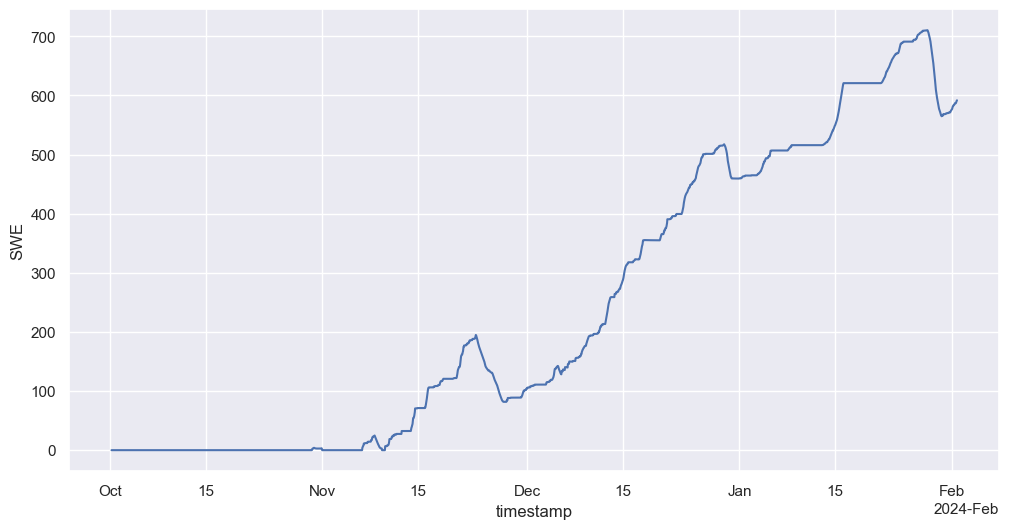

In [36]:
ds_snowpack.SWE.plot()

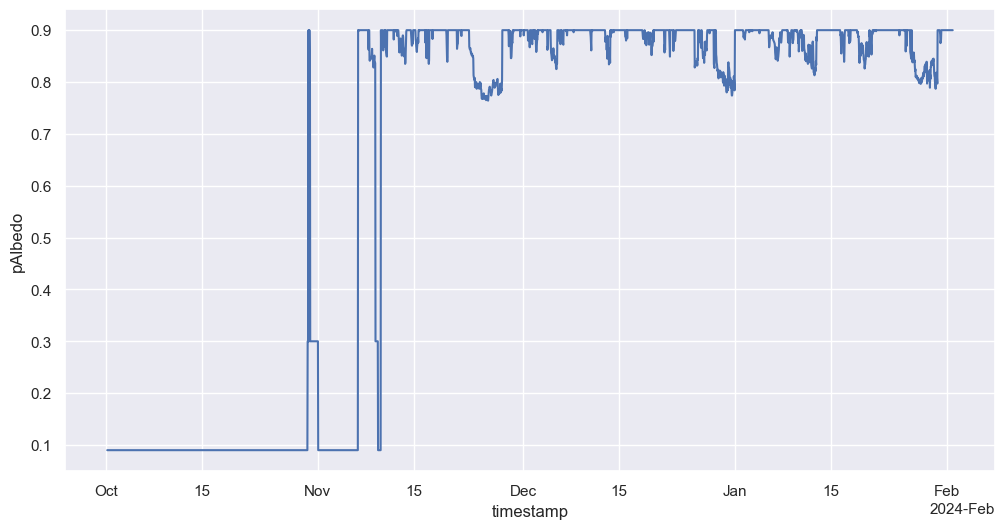

In [37]:
ds_snowpack.pAlbedo.plot()

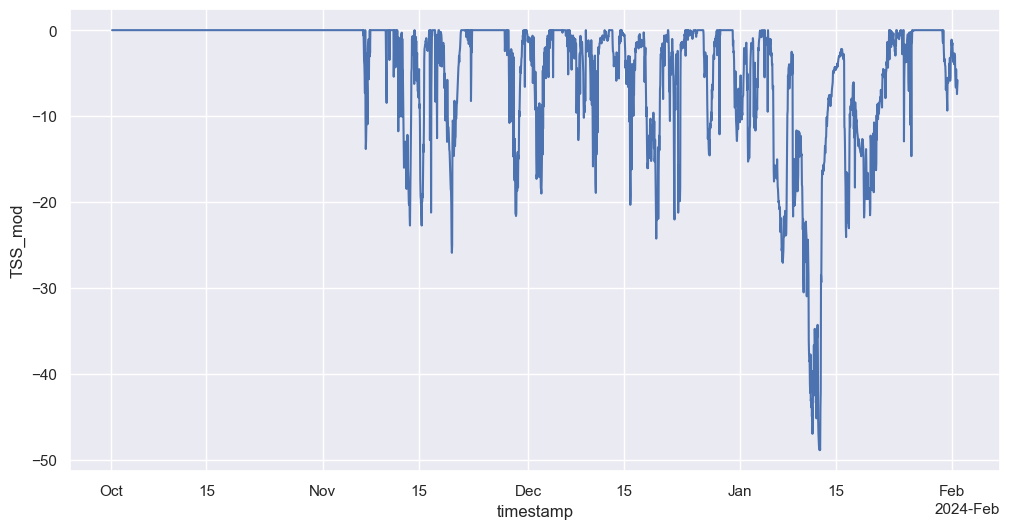

In [38]:
ds_snowpack.TSS_mod.plot()